# Seasonality 고려하기 

계절적 자기회귀누적이동평균 (Seasonal AutoRegressive Integrated Moving Average; SARIMA)   
SARIMA $(p,d,q)(P,D,Q)_m$: 시계열을 예측할 때 주기적 패턴을 고려할 수 있는 또 다른 매개변수 집합을 추가하므로 ARIMA(p,d,q) 모델로는 가능하지 않은 예측을 할 수 있음.  

---
시계열에서 계절 패턴을 식별하는 방법을 확인하고 계절적 시계열을 예측하기 위한 SARIMA 모델을 적용. 
- ex) 이 모델을 적용하여 한 항공사의 월별 총 승객 수를 예측. 

In [2]:
import pandas as pd

df = pd.read_csv('https://raw.githubusercontent.com/marcopeix/TimeSeriesForecastingInPython/refs/heads/master/data/air-passengers.csv')
df

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


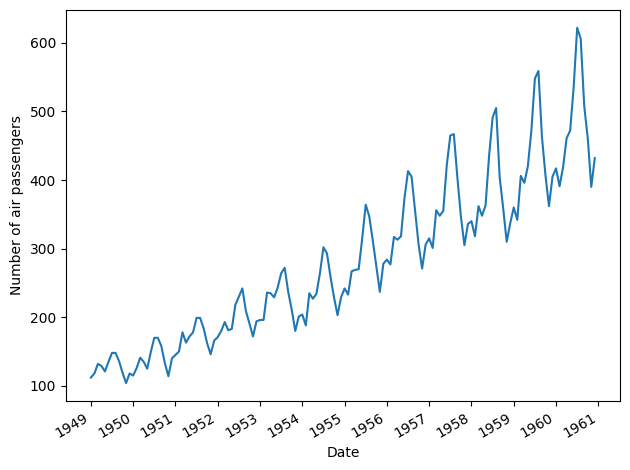

In [4]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots()

ax.plot(df['Month'], df['Passengers'])
ax.set_xlabel('Date')
ax.set_ylabel('Number of air passengers')

plt.xticks(np.arange(0, 145, 12), np.arange(1949, 1962, 1))

fig.autofmt_xdate()
plt.tight_layout()


도식: 계절적 패턴이 있음.
- 항공 승객 수는 연초와 연말에 낮고, 6/7/8월에 급증.

목표: 1년 동안의 월별 항공 승객 수를 예측.
- 항공사가 항공 승객 수를 예측하는 것은 항공권 가격을 더 잘 책정하고 특정 월의 수요를 충족하기 위해 항공편을 예약할 수 있도록 하기 위해 중요.

# 8.1 SARIMA $(p,d,q)(P,D,Q)_m$ 모델 살펴보기
SARIMA $(p,d,q)(P,D,Q)_m$ 는 **계절 매개변수**를 추가하여 ARIMA(p,d,q) 모델을 확장한 것.  
4가지의 새로운 매개변수
- (p,d,q): ARIMA(p,d,q)와 동일한 의미를 갖지만 계절에 따라 달라짐.
- m: 빈도 (계절적 주기당 관측 횟수)
    - 빈도: 주기당 관측 횟수; 데이터 집합에 따라 달라짐.
    - 매년, 분기, 월, 주 단위로 기록된 데이터의 경우 주기의 길이는 1년으로 간주.
        - 매년 기록된 경우, 1년에 관찰이 한 번만 있으므로 m = 1
        - 분기별 기록된 경우, m = 4
        - 월별로 기록된 경우, m = 12
        - 주간으로 기록된 경우, m = 52
    - 일별, 또는 일 하위 시간 단계로 수집되는 경우
        - 일별 데이터는 주간 계절성. m = 7 (1주는 7일이니까)
        - 연간 계절성: m = 365
    - 일별 데이터와 일 하위 시간 단계 데이터는 서로 다른 주기를 가질 수 있고, 다른 빈도 m을 가질 수 있음. 
- (P,D,Q): ARIMA(p,d,q) 모델의 p,d,q 매개변수에 계절적으로 상응하는 값. 
    - P: 계절적 AR(P) 프로세스의 차수
    - D: 계절적 적분 차수
    - Q: 계절적 MA(Q) 프로세스의 차수

**SARIMA $(p,d,q)(0,0,0)_m$ = ARIMA(p,d,q)**